# Instance Generation — San Cristóbal de La Laguna

This notebook orchestrates the generation of the HDM problem instance.
It calls the functions defined in `src/generador.py` and visualises
each intermediate result before serialising the final instance to JSON.

**Pipeline:**
1. Download and filter the pedestrian street network (OSMnx)
2. Extract candidate collection points (intersections, degree ≥ 3)
3. Extract buildings and estimate inhabitants (area proxy)
4. Compute sparse Dijkstra distances (cutoff = 350 m)
5. Assemble and save the instance to JSON

In [1]:
import sys
sys.path.insert(0, '../src/python')

import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point


from instancia import GeographicConfig, ModelParameters
from generador import download_graph, extract_candidates, extract_buildings

## 1. Geographic and model configuration

We define two configuration objects:
- `GeographicConfig` controls the OSMnx download area and graph filtering.
- `ModelParameters` holds all HDM/HVM cost and capacity parameters.

The `radius` parameter (800 m) defines the OSMnx download area.
The `cutoff_dijkstra` parameter (350 m) is stricter — it limits
which building–candidate pairs are considered reachable on foot.

In [2]:
config = GeographicConfig(
    place="Plaza del Cristo, San Cristóbal de La Laguna, España",
    radius=500,
    network_type="walk",
    cutoff_dijkstra=350,
    min_node_degree=3,
)

## 2. Street network
Pedestrian network filtered: motorway, trunk and variants removed.

Nodes:  250
Edges:  648


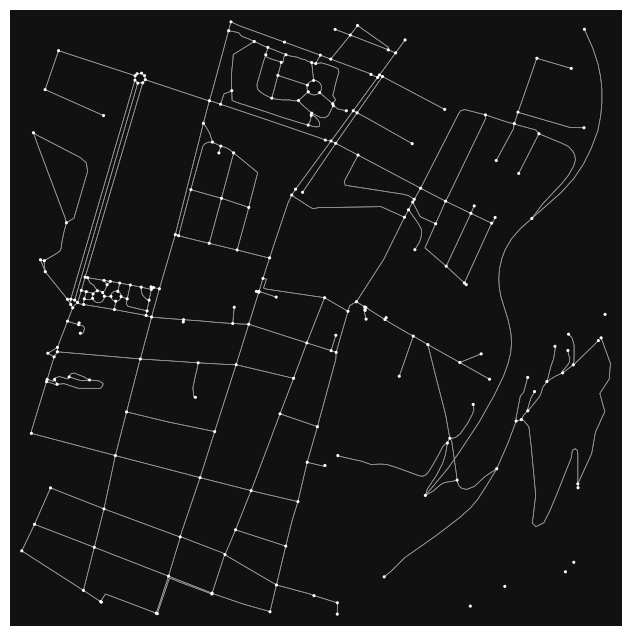

In [3]:
graph = download_graph(config)

print(f"Nodes:  {graph.number_of_nodes()}")
print(f"Edges:  {graph.number_of_edges()}")

fig, ax = ox.plot_graph(
    graph,
    node_size=5,
    edge_linewidth=0.5,
    show=True,
)

## 3. Candidate collection points
Intersections with degree ≥ 3. These are the potential locations for waste collection points.

In [4]:
candidates, idx_to_j, j_to_idx = extract_candidates(graph, config)

print(f"Candidates:      {len(candidates)}")
print(f"idx_to_j[0]:     {idx_to_j[0]}")
print(f"j_to_idx check:  {j_to_idx[idx_to_j[0]] == 0}")
print(f"Example:         {candidates[0]}")

Candidates:      212
idx_to_j[0]:     262190674
j_to_idx check:  True
Example:         CandidateData(osm_id='262190674', latitude=28.492838, longitude=-16.3156136)


## 4. Buildings and demand proxy
Building footprints from OSM. Inhabitants estimated as `area_m2 / ref_surface_m2`.

In [5]:
buildings, i_to_idx, idx_to_i = extract_buildings(config)

print(f"Buildings:        {len(buildings)}")
print(f"Total population: {sum(b.h_i for b in buildings.values()):.1f}")
print(f"Example:          {buildings[0]}")

Buildings:        740
Total population: 9701.2
Example:          BuildingData(osm_id="('relation', 1639376)", latitude=28.488123549675816, longitude=-16.31638697671205, h_i=209.72850176102773)


## 5. Spatial overview
Building footprints and candidate collection points overlaid on the street network.

In [6]:
# Load building footprints for visualisation only
buildings_gdf_viz = ox.features_from_address(
    config.place,
    tags={"building": True},
    dist=config.radius,
)
buildings_gdf_viz = buildings_gdf_viz[
    buildings_gdf_viz.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()

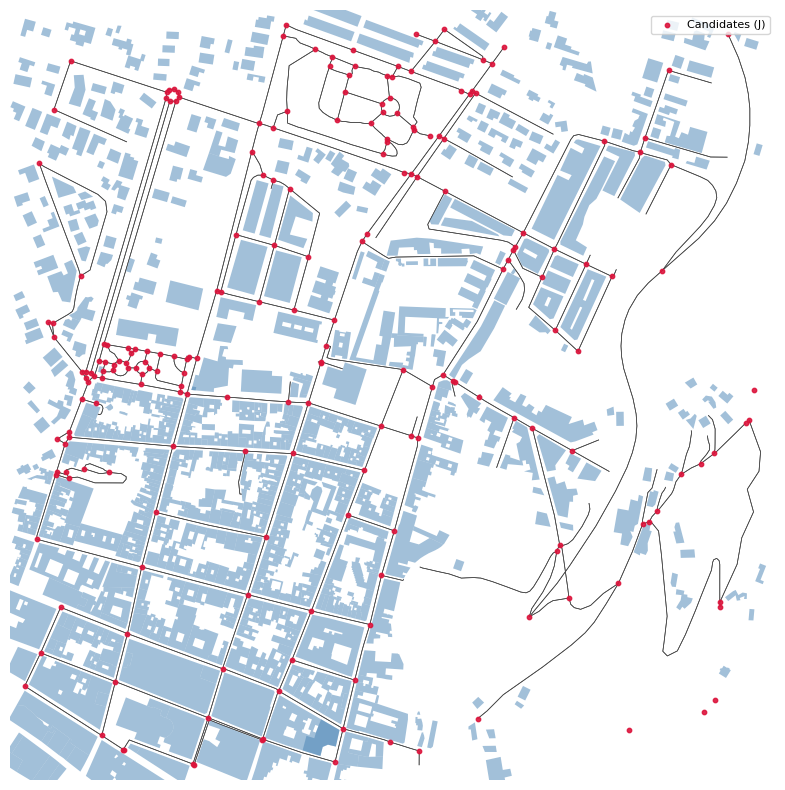

In [7]:
fig, ax = ox.plot_graph(
    graph,
    show=False,
    close=False,
    node_size=0,
    edge_linewidth=0.5,
    edge_color="#444444",
    bgcolor="white",
)

buildings_gdf_viz.plot(
    ax=ax,
    color="steelblue",
    alpha=0.5,
    edgecolor="none",
)

ax.scatter(
    [c.longitude for c in candidates.values()],
    [c.latitude for c in candidates.values()],
    c="crimson", s=10, alpha=0.9, zorder=5, label="Candidates (J)",
)

ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Parks:       8
Squares:     3
Roundabouts: 0


ValueError: aspect must be finite and positive 

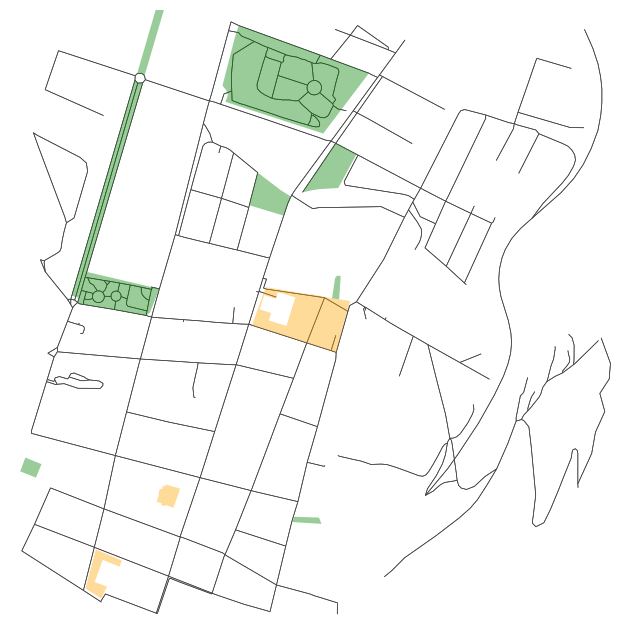

In [ ]:
import matplotlib.patches as mpatches

# Download context polygons
parks = ox.features_from_address(config.place, tags={"leisure": "park"}, dist=config.radius)
squares = ox.features_from_address(config.place, tags={"place": "square"}, dist=config.radius)
roundabouts = ox.features_from_address(config.place, tags={"junction": "roundabout"}, dist=config.radius)

# Keep only polygons
parks = parks[parks.geometry.type.isin(["Polygon", "MultiPolygon"])]
squares = squares[squares.geometry.type.isin(["Polygon", "MultiPolygon"])]
roundabouts = roundabouts[roundabouts.geometry.type.isin(["Polygon", "MultiPolygon"])]

print(f"Parks:       {len(parks)}")
print(f"Squares:     {len(squares)}")
print(f"Roundabouts: {len(roundabouts)}")

# Plot
fig, ax = ox.plot_graph(
    graph, show=False, close=False,
    node_size=0, edge_linewidth=0.5,
    edge_color="#444444", bgcolor="white",
)

if len(parks) > 0:      parks.plot(ax=ax, color="green", alpha=0.4)
if len(squares) > 0:    squares.plot(ax=ax, color="orange", alpha=0.4)
if len(roundabouts) > 0: roundabouts.plot(ax=ax, color="purple", alpha=0.6)

parks.plot(ax=ax,      color="green",  alpha=0.4)
squares.plot(ax=ax,    color="orange", alpha=0.4)
roundabouts.plot(ax=ax, color="purple", alpha=0.6)

ax.scatter(
    [c.longitude for c in candidates.values()],
    [c.latitude for c in candidates.values()],
    c="crimson", s=10, zorder=5,
)

legend = [
    mpatches.Patch(color="green",  alpha=0.6, label="Park"),
    mpatches.Patch(color="orange", alpha=0.6, label="Square"),
    mpatches.Patch(color="purple", alpha=0.6, label="Roundabout"),
]
ax.legend(handles=legend, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()